In [1]:
# DAY 4 - SETUP

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

In [2]:
# DAY 4 - LOAD DATA

nav = pd.read_csv("../data/processed/clean_nav.csv")

fund_master = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

benchmark = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(nav.shape)
print(fund_master.shape)
print(performance.shape)

(46000, 3)
(40, 15)
(40, 21)


In [3]:
# TASK 1 - DAILY RETURNS

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

daily_returns = nav.copy()

daily_returns.to_csv(
    "../reports/daily_returns.csv",
    index=False
)

daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
# TASK 2 - CAGR

cagr_data = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    start_nav = grp["nav"].iloc[0]
    end_nav = grp["nav"].iloc[-1]

    years = (
        grp["date"].max()
        -
        grp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    ) * 100

    cagr_data.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code","CAGR"]
)

cagr_df.to_csv(
    "../reports/cagr_report.csv",
    index=False
)

cagr_df.head()

,amfi_code,CAGR
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [5]:
# TASK 3 - SHARPE RATIO

RF = 0.065

sharpe_list = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    annual_return = r.mean()*252

    annual_std = r.std()*np.sqrt(252)

    sharpe = (
        annual_return - RF
    ) / annual_std

    sharpe_list.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code","Sharpe"]
)

sharpe_df.to_csv(
    "../reports/sharpe_values.csv",
    index=False
)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [6]:
# TASK 4 - SORTINO

sortino_list = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    downside = r[r<0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        r.mean()*252
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_list.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code","Sortino"]
)

sortino_df.to_csv(
    "../reports/sortino_values.csv",
    index=False
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [7]:
# TASK 5 - ALPHA BETA

nifty = benchmark[
    benchmark["index_name"]
    ==
    "NIFTY100"
].copy()

alpha_beta = []

for code, grp in nav.groupby("amfi_code"):

    fund = grp[
        ["date","daily_return"]
    ]

    merged = pd.merge(
        fund,
        nifty,
        on="date",
        how="inner"
    )

    if len(merged) < 30:
        continue

    merged["benchmark_return"] = (
        merged["close_value"]
        .pct_change()
    )

    merged = merged.dropna()

    slope, intercept, *_ = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [code,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [8]:
# TASK 6 - MAX DRAWDOWN

drawdowns = []

for code, grp in nav.groupby("amfi_code"):

    running_max = (
        grp["nav"].cummax()
    )

    dd = (
        grp["nav"]
        /
        running_max
        -
        1
    )

    drawdowns.append(
        [code,dd.min()]
    )

maxdd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

maxdd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

maxdd_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [9]:
# TASK 7 - FUND SCORECARD

scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    maxdd_df,
    on="amfi_code"
)

scorecard["Score"] = (
    scorecard["CAGR"].rank(pct=True)*30
    +
    scorecard["Sharpe"].rank(pct=True)*25
    +
    scorecard["Alpha"].rank(pct=True)*20
    +
    scorecard["Max_Drawdown"]
        .rank(ascending=False,pct=True)*10
)

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard.head()

,amfi_code,CAGR,Sharpe,Alpha,Beta,Max_Drawdown,Score
25,120505,32.801599,1.180101,0.292636,0.000549,-0.181885,77.750
36,148569,31.924486,1.234930,0.282704,0.018134,-0.163967,75.250
21,119598,32.398084,0.945308,0.303370,-0.023196,-0.287060,75.125
39,149324,32.262108,0.949796,0.300579,0.011455,-0.311719,74.750
30,120843,30.883326,1.306744,0.273305,-0.022830,-0.129740,71.875


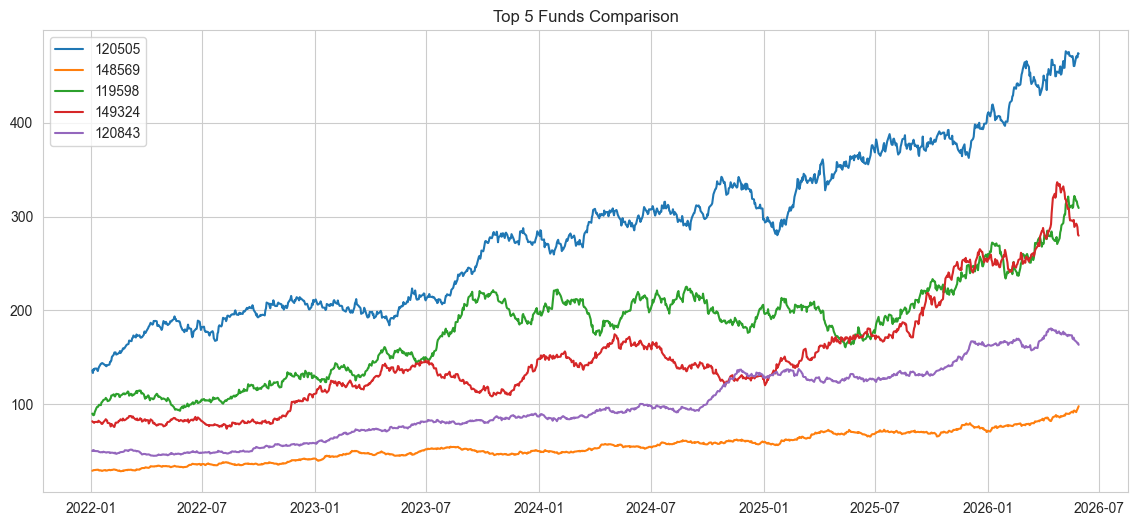

In [11]:
# TASK 8 - BENCHMARK COMPARISON

top5 = (
    scorecard["amfi_code"]
    .head(5)
    .tolist()
)

plt.figure(figsize=(14,6))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds Comparison"
)

plt.savefig(
    "../reports/benchmark_chart.png"
)

plt.show()